In [20]:
import torch
import numpy as np
from copy import deepcopy
import pickle as pkl

from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from utils_plot import *
from tqdm import tqdm
from utils import *
from functools import reduce
import os
from joblib import Parallel, delayed
import shutil

# http://localhost:8080/tree?token=98ea3fcb0b09366b2803c421736080a9ed9f4ca179479adf

In [21]:
# import pandas as pd
# df_hyper = pd.read_pickle("figures/scan_MNIST/results_summary.df")
# df_hyper.sort_values(by='r2', ascending=False, inplace=True)
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6,4))
# plt.scatter(df_hyper['mse_loss'], df_hyper['r2'], alpha=0.7)
# plt.xlabel('MSE Loss')
# plt.ylabel('R2')
# plt.title('Scatter of MSE Loss vs R2')
# plt.grid(True)
# plt.show()

In [22]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [23]:
C = Config()

C.G = 0.5
C.sig_h_2 = 1e-3
C.linear_net = True
C.learning_rate = 0.0001
C.L=5
C.length_corridors = [20]*1
C.max_move = 10
C.hidden_size = 100
C.num_epochs = 10000
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.omit_indices = [10]
C.use_gpu = False
C.print_progress = True

var_name = 'L'
var_values = np.arange(1, 6, 1) # [1, C.length_corridors[0]//4, C.length_corridors[0]//2, 3*C.length_corridors[0]//4, C.length_corridors[0]-1] # np.arange(C.length_corridors[0]) #  


In [24]:
num_gpus = 8

# Ensure the results directory exists
results_dir = f'results/notebook_results/circular/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value, index):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    n_samples = C_local.length_corridors[0]*(C_local.max_move*2+1)-(np.arange(C_local.max_move+1).sum()*2)
    n_omit = max(5, n_samples//5)
    C_local.omit_indices = list(np.random.choice(n_samples, size=n_omit, replace=False))
    # if var_name == 'L':
    #     C_local.learning_rate = C.learning_rate * 0.2**C_local.L
    C_local.gpu_id = index % num_gpus
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{getattr(C_local, var_name)}.pkl')
    # Remove 'state_dict_l' and 'hidden_l' from data_dict if they exist
    data_dict.pop('state_dict_l', None)
    data_dict.pop('hidden_l', None)
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value, index) for index, var_value in enumerate(var_values)
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

Number of samples: 310
Input dimension: 41
Output dimension: 20
Number of actions: 21

Changed G to 0.5773963332176208 to get sig_h_2 = 0.001
Sig_2 of last hidden: 0.0010205123107880354
Number of samples: 310
Input dimension: 41
Output dimension: 20
Number of actions: 21

Changed G to 0.7192575335502625 to get sig_h_2 = 0.001
Sig_2 of last hidden: 0.0009645101963542402
Number of samples: 310
Input dimension: 41
Output dimension: 20
Number of actions: 21

Changed G to 0.1924961805343628 to get sig_h_2 = 0.001
Sig_2 of last hidden: 0.0010290594073012471
Number of samples: 310
Input dimension: 41
Output dimension: 20
Number of actions: 21

Changed G to 0.43874385952949524 to get sig_h_2 = 0.001
Number of samples: 310
Input dimension: 41
Output dimension: 20
Number of actions: 21

Sig_2 of last hidden: 0.001090839272364974
Changed G to 0.6623774170875549 to get sig_h_2 = 0.001
Sig_2 of last hidden: 0.0010791426757350564


100%|██████████| 10000/10000 [00:53<00:00, 188.57it/s]


L: 1 --- X shape: torch.Size([310, 41]) --- Number of hidden: 100
L: 2 --- X shape: torch.Size([310, 41]) --- Number of hidden: 100
L: 3 --- X shape: torch.Size([310, 41]) --- Number of hidden: 100
L: 4 --- X shape: torch.Size([310, 41]) --- Number of hidden: 100
L: 5 --- X shape: torch.Size([310, 41]) --- Number of hidden: 100


In [25]:
def plot_pca(data_dict, title="", axs=None): # of eneven corridors
    loc_y = data_dict['loc_y']
    hidden_states = data_dict['hidden_states']
    action_taken = data_dict['action_taken']
    loss_l = data_dict['loss_l']; accuracy_l = data_dict['accuracy_l']
    y = data_dict['y'].cpu().numpy()
    C = data_dict['C']
    corridor = data_dict['corridor']
    X_np = data_dict['X'].cpu().numpy()
    final_weights = data_dict['final_weights']

    hidden = hidden_states[-1].cpu().detach().numpy()
    hidden_dist = torch.cdist(hidden_states[-1], hidden_states[-1]).cpu().numpy()

    PR = calc_PR(hidden)
    if not C.bias:
        W_effective = get_effective_W_from_model_dict(final_weights).cpu().numpy()
        W_PR = calc_PR(W_effective)
        if C.L == 0:
            U, S, V = np.linalg.svd(W_effective, full_matrices=False)
            hidden = X_np @ U @ np.diag(S)
            hidden_dist = torch.cdist(torch.tensor(hidden), torch.tensor(hidden)).cpu().numpy()
    else:
        W_PR = 0
    hidden_pr = calc_PR(hidden)

    # alignment = alignment_score(hidden[corridor==0], hidden[corridor==1]) if n_corridors > 1 else 0
    order = get_r_2(PCA(n_components=1).fit_transform(hidden), loc_y)

    pca = PCA().fit(hidden)
    X_reduced = pca.transform(hidden)
    if axs is None:
        fig, axs = plt.subplots(1, 5, figsize=(25/2, 5/2))
        axs[0].set_ylabel(title)
    # Add cumulative explained variance ratio in the first row
    ax1 = axs[0]
    ax1.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    ax1.set_xlabel('Number of Components')
    # ax1.set_ylabel('Cumulative EVR')
    ax1.set_title(f'order = {order:.2f} --- W PR = {W_PR:.2f} --- hidden PR = {hidden_pr:.2f}')
    ax1.set_ylim(-0.1, 1.1)

    ax1 = axs[1]
    for cor, marker in zip(np.unique(corridor), markers):
        print(X_reduced.shape, loc_y.shape)
        ax1.scatter(X_reduced[corridor==cor, 0], X_reduced[corridor==cor, 1], c=loc_y[corridor==cor, 0], cmap='coolwarm', alpha=0.7, marker=marker)
    ax1.set_xlabel(f'Component 1')
    ax1.set_ylabel(f'Component 2'),
    ax1.axis('equal')

    ax1 = axs[2]
    for cor, marker in zip(np.unique(corridor), markers):
        ax1.scatter(X_reduced[corridor==cor, 0], X_reduced[corridor==cor, 1], c=loc_y[corridor==cor, 1], cmap='coolwarm', alpha=0.7, marker=marker)
    ax1.set_xlabel(f'Component 1')
    ax1.set_ylabel(f'Component 2'),
    ax1.axis('equal')

    axs[3].plot(loss_l)
    axs[3].set_yscale('log')
    ax2 = axs[3].twinx()
    ax2.plot(accuracy_l, 'r')
    ax2.set_ylim(-0.1, 1.1)
    axs[3].set_title("Loss")

    axs[4].imshow(hidden_dist[y.argmax(1).argsort()][:, y.argmax(1).argsort()], cmap='viridis')
    axs[4].set_title('hidden distance matrix')
    axs[4].grid(False)

    plt.tight_layout()

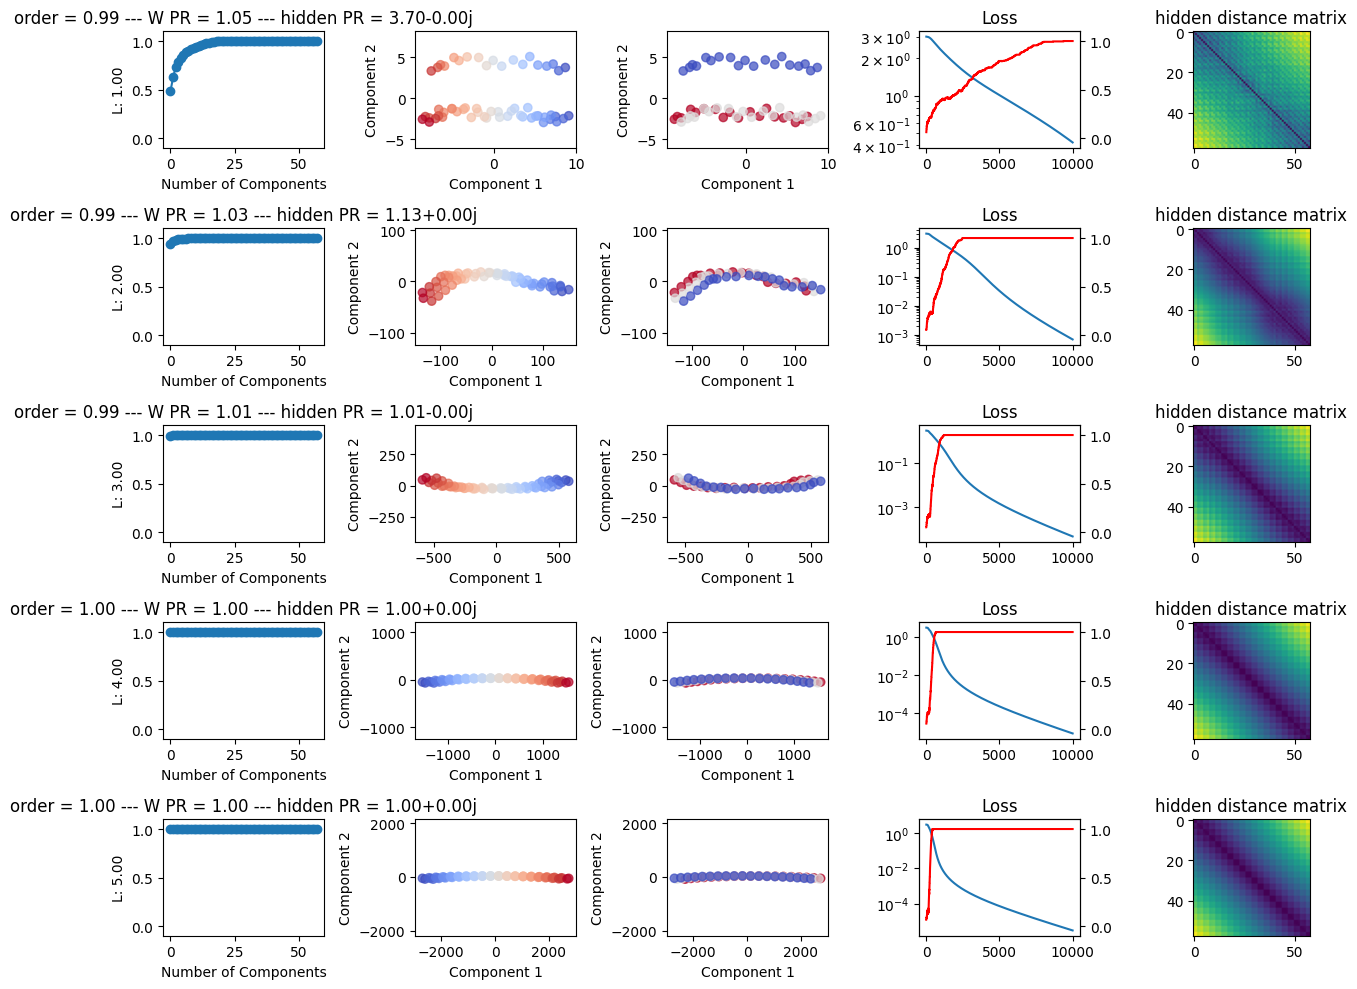

In [26]:
from utils_plot import plot_pca
fig, axs = plt.subplots(len(data_dict_l), 5, figsize=(25/2, len(data_dict_l)*4/2))
for data_dict, axs_current in zip(data_dict_l, axs):
    plot_pca(data_dict, axs=axs_current)
    axs_current[0].set_ylabel(f'{var_name}: {getattr(data_dict["C"], var_name):.2f}')
fig.savefig(r'.\wide.png', dpi=300, bbox_inches='tight')

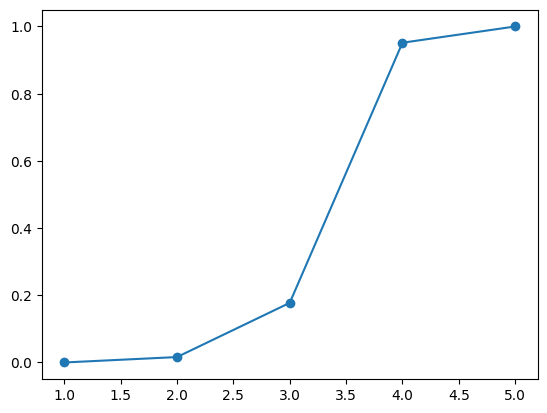

In [27]:
plt.plot(var_values, [d['accuracy_test_l'][-1] for d in data_dict_l], marker='o')
plt.show()

In [28]:
[len(d['C'].omit_indices) for d in data_dict_l]

[62, 62, 62, 62, 62]